<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/16_RandomForest_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존**과 **정보누수 방지**가 핵심입니다.


## 0) 환경 준비
```bash
pip install yfinance
```


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [4]:
# 데이터 수집 (최근 1년)
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 247


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성(과거 정보만 사용)


In [5]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 228


## 3) 타깃/분할(시간 순서 보존)


In [6]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (181, 7) Test: (46, 7)


### 🔍 피처(Feature) 상세 설명

모델의 예측 성능을 높이기 위해 사용된 7가지 기술적 지표의 의미는 다음과 같습니다.

1.  **`ret_lag1` ~ `ret_lag10` (Lagged Returns)**:
    *   **설명**: 각각 1일 전, 2일 전, 3일 전, 5일 전, 10일 전의 주가 수익률입니다.
    *   **의도**: 과거의 수익률 패턴이 내일의 방향성에 영향을 주는지 학습합니다 (예: 어제 올랐으면 오늘도 오를까?).

2.  **`ma_gap` (MA Cross Over Distance)**:
    *   **계산**: `(5일 이동평균 / 20일 이동평균) - 1.0`
    *   **설명**: 단기 평단가(5일)와 중기 평단가(20일) 사이의 이격도입니다.
    *   **의도**: 단기 추세가 장기 추세 대비 얼마나 과열되었는지 또는 골든/데드크로스 근처에 있는지를 나타냅니다.

3.  **`vol10` (Rolling Volatility)**:
    *   **계산**: 최근 10일간 수익률의 표준편차(Standard Deviation)
    *   **설명**: 최근 시장의 변동성(위험도)을 측정합니다.
    *   **의도**: 시장이 불안정한 상태(고변동성)인지 안정적인 상태(저변동성)인지에 따라 상승 확률이 달라지는지 확인합니다.

## 4) 모델: Random Forest (랜덤 포레스트)

랜덤 포레스트는 여러 개의 **결정 트리(Decision Tree)**를 결합하여 예측력을 높이는 **앙상블(Ensemble) 기법** 중 하나인 **배깅(Bagging)**의 대표적인 모델입니다.

### 앙상블의 핵심 원리
1.  **부트스트랩(Bootstrap)**: 전체 데이터에서 중복을 허용하여 샘플을 무작위로 추출합니다.
2.  **무작위 특징 선택**: 각 트리를 분할할 때 모든 피처를 다 쓰지 않고, 무작위로 일부 피처만 선택하여 트리 간의 상관관계를 낮춥니다.
3.  **다수결(Aggregation)**: 각 트리가 내놓은 결과를 취합하여 최종 결과를 결정합니다.

### 수학적 표현
랜덤 포레스트의 최종 분류 결과 $H(x)$는 $K$개의 개별 트리 $h_k(x)$의 투표 결과로 결정됩니다.

$$H(x) = \text{arg max}_{y \in \{0, 1\}} \sum_{k=1}^{K} I(h_k(x) = y)$$

여기서 $I(\cdot)$는 지시 함수(Indicator function)로, 조건이 참이면 1, 거짓이면 0을 반환합니다.

### 구조도 예시
```
[Data Sample] --> [Tree 1] --> [Result: Up]
              --> [Tree 2] --> [Result: Down]  ==> [Final Vote: Up]
              --> [Tree 3] --> [Result: Up]
```

In [7]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


RandomForestClassifier(max_depth=6, min_samples_leaf=10, n_estimators=300,
                       n_jobs=-1, random_state=42)

## 5) 평가


Accuracy: 0.4348
ROC-AUC : 0.5246

Classification report:
              precision    recall  f1-score   support

           0     0.1667    0.0455    0.0714        22
           1     0.4750    0.7917    0.5938        24

    accuracy                         0.4348        46
   macro avg     0.3208    0.4186    0.3326        46
weighted avg     0.3275    0.4348    0.3439        46



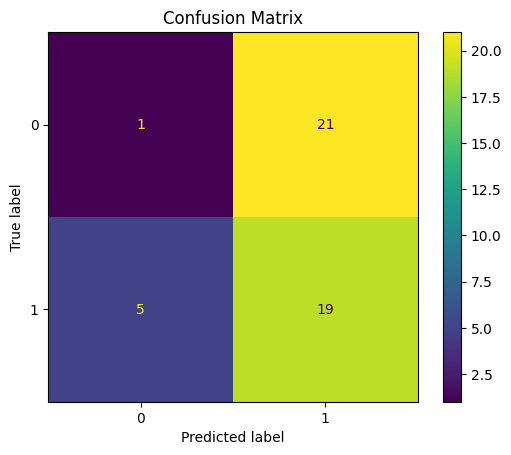

In [8]:
# 평가
y_pred = model.predict(X_test)
# 확률 예측이 가능한 모델이면 AUC도 계산
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
if auc is not None:
    print(f"ROC-AUC : {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


## ✅ 마지막 시각화: ROC Curve + 변수 중요도(Top 10)


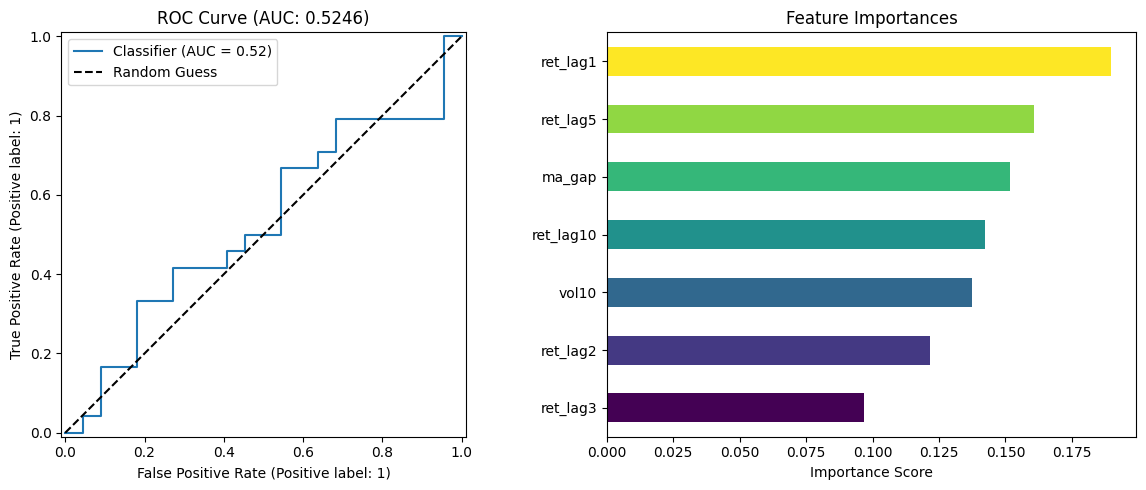


[시각화 결과 해석]
1. ROC-AUC: 0.5246 - 모델의 분류 능력을 나타냅니다. 0.5는 무작위 추측이며, 1에 가까울수록 우수합니다.
2. 최상위 변수: 'ret_lag1' 변수가 예측에 가장 큰 영향을 미치고 있습니다.
3. 혼동 행렬 분석: Precision과 Recall을 통해 모델이 상승(1)을 더 잘 맞추는지, 하락(0)을 더 잘 맞추는지 확인 가능합니다.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import RocCurveDisplay

# 1. ROC Curve 시각화 및 해석
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
y_proba = model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba, ax=plt.gca())
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title(f'ROC Curve (AUC: {auc:.4f})')
plt.legend()

# 2. 변수 중요도 시각화 및 해석
plt.subplot(1, 2, 2)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(importances)))
importances.plot(kind='barh', color=colors)
plt.title('Feature Importances')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\n[시각화 결과 해석]")
print(f"1. ROC-AUC: {auc:.4f} - 모델의 분류 능력을 나타냅니다. 0.5는 무작위 추측이며, 1에 가까울수록 우수합니다.")
print(f"2. 최상위 변수: '{importances.index[-1]}' 변수가 예측에 가장 큰 영향을 미치고 있습니다.")
print("3. 혼동 행렬 분석: Precision과 Recall을 통해 모델이 상승(1)을 더 잘 맞추는지, 하락(0)을 더 잘 맞추는지 확인 가능합니다.")

## 8) 방향 예측(Up/Down) 출력 + 다음 거래일 예측
아래는 분류 모델의 예측을 ‘방향’ 관점에서 요약하고,
마지막 관측치의 특징으로 다음 거래일(표시상 +1일)의 Up/Down을 출력합니다.
※ 실제 거래일 캘린더(휴장일)는 반영하지 않습니다.


In [10]:
import numpy as np
import pandas as pd

# 예측된 값 (0: 하락, 1: 상승)의 개수 계산
prediction_counts = np.bincount(y_pred)

# 예측 결과 출력
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

# 마지막 관측치로 '다음 거래일' 방향 예측(예: 오늘 기준 내일 Up/Down)
last_day_features = X.iloc[-1].values.reshape(1, -1)

# 모델별 입력 형식 처리: Pipeline(예: SVM)은 그대로 넣으면 scaler까지 적용됨
next_day_prediction = model.predict(last_day_features)

prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

# 예측 날짜(단순히 마지막 날짜 + 1일로 표시)
last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 6 건
Predicted Up (상승): 40 건
다음 거래일 예측 (날짜: 2026-03-24): 상승 (Up)


## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
